## Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

palette = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # purple
    "#000000"   # black
]

REPORTS_DIR = Path.cwd() / "reports"

## Load Reports

In [2]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 10


## Convert to DataFrames

In [ ]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [ ]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [ ]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [ ]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [ ]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section      Structure                                        Callsites  \
metric           Files     Nodes     Edges Observed Syntactic Callsites   
repo                                                                      
airbyte         3288.0   25275.0   38063.0                      15626.0   
commons-lang     534.0   11566.0   17316.0                       5692.0   
eslint          1499.0    2905.0    2846.0                        689.0   
guava           3245.0   64131.0  103276.0                      36639.0   
npm-cli         1545.0    9167.0   14029.0                       5445.0   
pydantic         407.0   13301.0   16283.0                       3263.0   
rollup         12474.0   19557.0   20341.0                      11852.0   
sympy           1590.0   40980.0   99191.0                      72663.0   
vscode          6765.0  108097.0  346645.0                     155451.0   
webpack         8703.0   14945.0   14428.0                       3368.0   

section                                                                   \
metric       Filtered Pre-Persist Persisted Callsites Persisted Accepted   
repo                                                                       
airbyte                     896.0             14730.0            14441.0   
commons-lang                205.0              5487.0             5376.0   
eslint                       37.0               652.0              639.0   
guava                      1266.0             35373.0            34844.0   
npm-cli                     393.0              5052.0             4796.0   
pydantic                    848.0              2415.0             2273.0   
rollup                     3700.0              8152.0             8087.0   
sympy                     25344.0             47319.0            47109.0   
vscode                    10208.0            145243.0           141486.0   
webpack                     156.0              3212.0             3135.0   

section                          Pre-Persist Filter                           \
metric       Persisted Dropped No In-Repo Candidate Accepted Outside In-Repo   
repo                                                                           
airbyte                  289.0                896.0                      0.0   
commons-lang             111.0                205.0                      0.0   
eslint                    13.0                 37.0                      0.0   
guava                    529.0               1266.0                      0.0   
npm-cli                  256.0                393.0                      0.0   
pydantic                 142.0                848.0                      0.0   
rollup                    65.0               3700.0                      0.0   
sympy                    210.0              25344.0                      0.0   
vscode                  3757.0              10208.0                      0.0   
webpack                   77.0                156.0                      0.0   

section       ...                 Timing                            \
metric        ... Build Structural Index Compute Build Fingerprint   
repo          ...                                                    
airbyte       ...              21.373260                  0.851458   
commons-lang  ...               6.489825                  0.368914   
eslint        ...               7.703025                  0.265613   
guava         ...              34.214596                  0.232071   
npm-cli       ...              11.537149                  0.363011   
pydantic      ...               7.231047                  0.233756   
rollup        ...              20.121201                  0.396893   
sympy         ...              38.140406                  0.517625   
vscode        ...             139.329995                  1.289805   
webpack       ...              15.693623                  0.391171   

section                                                                       \
met

In [ ]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)
timing_std = timing_total_df.std(numeric_only=True)

timing_mean.name = "Mean"
timing_median.name = "Median"
timing_std.name = "Std"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_std.to_frame().T, timing_median.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
pydantic,17.77,13301.00,16283.00,29584.00,1.34,1.09,0.60
commons-lang,17.90,11566.00,17316.00,28882.00,1.55,1.03,0.62
eslint,19.12,2905.00,2846.00,5751.00,6.58,6.72,3.32
npm-cli,28.77,9167.00,14029.00,23196.00,3.14,2.05,1.24
webpack,49.20,14945.00,14428.00,29373.00,3.29,3.41,1.67
airbyte,56.30,25275.00,38063.00,63338.00,2.23,1.48,0.89
rollup,63.02,19557.00,20341.00,39898.00,3.22,3.10,1.58
guava,100.82,64131.00,103276.00,167407.00,1.57,0.98,0.60
sympy,140.88,40980.00,99191.00,140171.00,3.44,1.42,1.01
vscode,632.54,108097.00,346645.00,454742.00,5.85,1.82,1.39


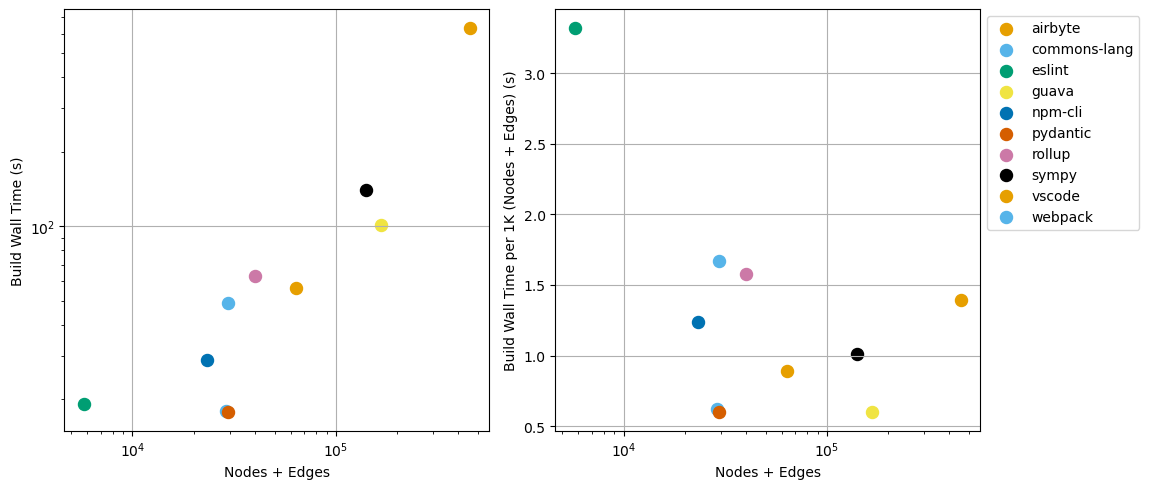

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(totals_pivot.index):
    color = palette[i % len(palette)]
    x = timing_overview_df.loc[repo, "Nodes + Edges"]
    y1 = timing_overview_df.loc[repo, "Build Wall Time"]
    y2 = timing_overview_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=75, label=repo)
    axes[1].scatter(x, y2, color=color, s=75)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

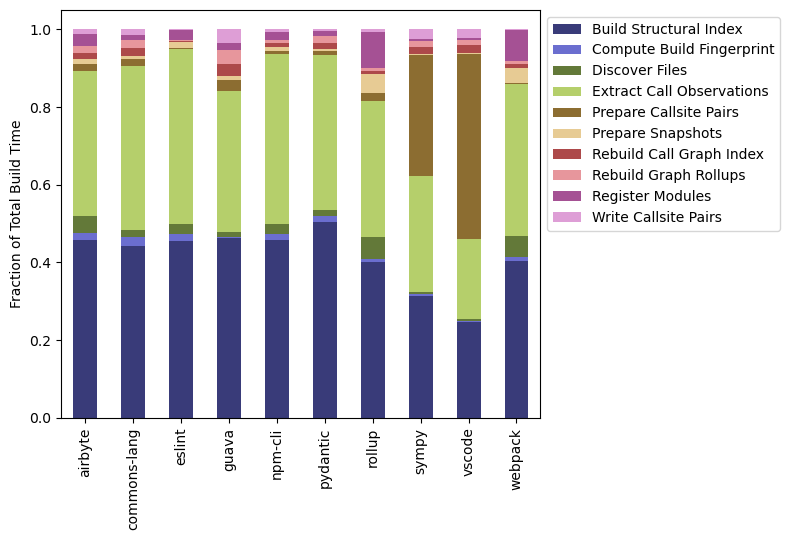

In [ ]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time"])
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap="tab20b", figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

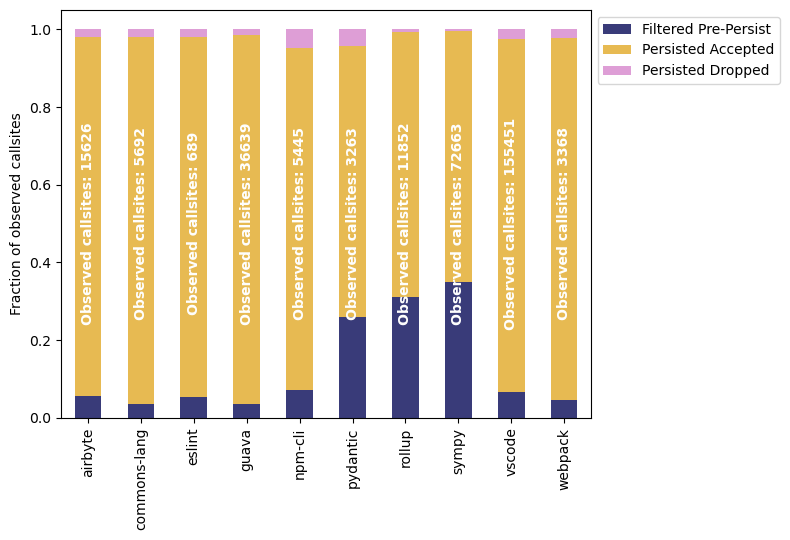

In [ ]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap="tab20b", ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

## Language breakdown

In [ ]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Structure                  \
metric                      Files   Nodes   Edges   
repo         language                               
airbyte      java             473    4144    5397   
             javascript        44     147     180   
             python          2768   20976   32478   
             typescript         3       8       8   
commons-lang java             534   11566   17316   
eslint       javascript      1474    2807    2762   
             typescript        25      98      84   
guava        java            3243   64129  103276   
             javascript         2       2       0   
npm-cli      javascript      1487    7721   11225   
             python            58    1446    2804   
pydantic     javascript         6      16      18   
             python           401   13285   16265   
rollup       javascript     12118   17143   13939   
             typescript       356    2414    6402   
sympy        python          1590   40980   99191   
vscode       java               1       5       4   
             javascript       105     392     414   
             python             3      14      11   
             typescript      6656  107686  346216   
webpack      javascript      8615   14757   14312   
             typescript        88     188     116   

section                                    Callsites                       \
metric                  Observed Syntactic Callsites Filtered Pre-Persist   
repo         language                                                       
airbyte      java                               1623                   54   
             javascript                           53                    0   
             python                            13948                  842   
             typescript                            2                    0   
commons-lang java                               5692                  205   
eslint       javascript                          689                   37   
             typescript                            0                    0   
guava        java                              36639                 1266   
             javascript                            0                    0   
npm-cli      javascript                         4050                  363   
             python                             1395                   30   
pydantic     javascript                            8                    0   
             python                             3255                  848   
rollup       javascript                         9493                 3506   
             typescript                         2359                  194   
sympy        python                            72663                25344   
vscode       java                                  0                    0   
             javascript                          125                    1   
             python                                0                    0   
             typescript                       155326                10207   
webpack      javascript                         3356                  156   
             typescript                           12                    0   

section                                                         \
metric                  Persisted Callsites Persisted Accepted   
repo         language                                            
airbyte      java                      1569               1556   
             javascript                  53                 53   
             python                   13106              12830   
             typescript                   2                  2   
commons-lang java                      5487               5376   
eslint       javascript                 652                639   
             typescript                   0                  0   
guava        java                     35373              34844   
             javascrip

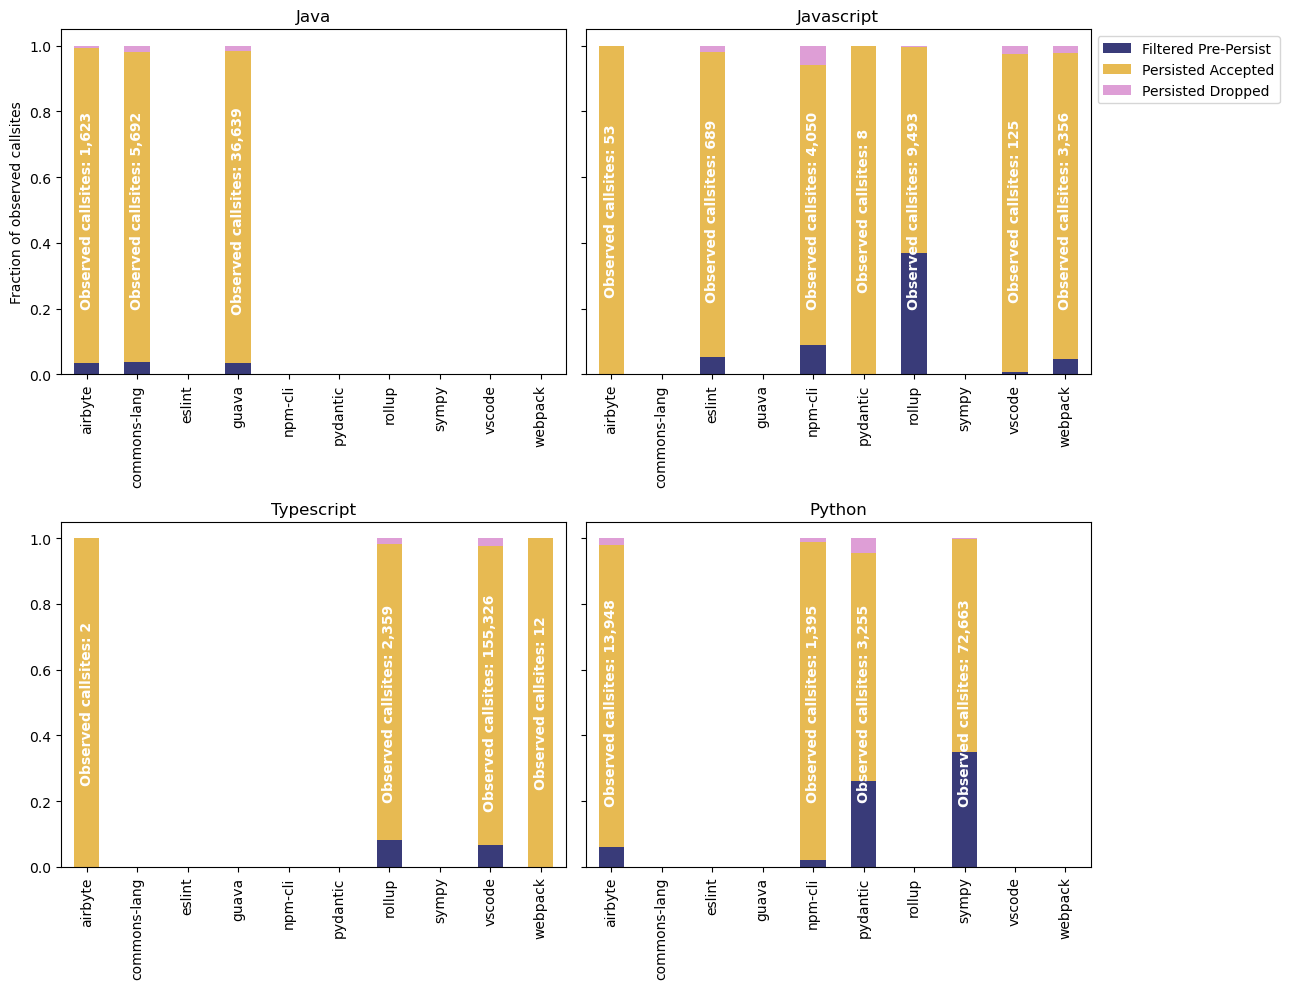

In [ ]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

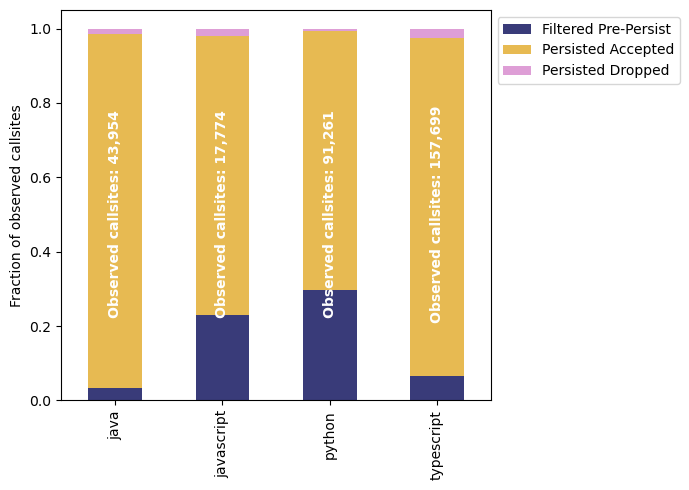

In [ ]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap="tab20b", ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [ ]:
callsites_raw_df

section    Structure                                    Callsites  \
metric         Files   Nodes   Edges Observed Syntactic Callsites   
language                                                            
java            4251   79844  125993                        43954   
javascript     23851   42985   42850                        17774   
python          4820   76701  150749                        91261   
typescript      7128  110394  352826                       157699   

section                                                                 \
metric     Filtered Pre-Persist Persisted Callsites Persisted Accepted   
language                                                                 
java                       1525               42429              41776   
javascript                 4063               13711              13353   
python                    27064               64197              63554   
typescript                10401              147298             143503   

section                        Pre-Persist Filter                           \
metric     Persisted Dropped No In-Repo Candidate Accepted Outside In-Repo   
language                                                                     
java                     653                 1525                        0   
javascript               358                 4063                        0   
python                   643                27064                        0   
typescript              3795                10401                        0   

section                              Call Materialization                       
metric     Invalid Observation Shape       Callsite Pairs Finalized Call Edges  
language                                                                        
java                               0                43385                43345  
javascript                         0                13493                13463  
python                             0                63554                62154  
typescript                         0               179106               177379

In [ ]:
callsites_df

metric,Filtered Pre-Persist,Persisted Accepted,Persisted Dropped
language,,,
java,0.034695,0.950448,0.014856
javascript,0.228592,0.751266,0.020142
python,0.296556,0.696398,0.007046
typescript,0.065955,0.909980,0.024065


## Scope breakdown

In [ ]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Structure                                   Callsites  \
metric                     Files  Nodes   Edges Observed Syntactic Callsites   
repo         scope                                                             
airbyte      Non-Tests      3098  23583   35939                        15012   
             Tests           190   1692    2124                          614   
commons-lang Non-Tests       259   4973    8643                         3403   
             Tests           275   6593    8673                         2289   
eslint       Non-Tests       477   1714    2229                          670   
             Tests          1022   1191     617                           19   
guava        Non-Tests      2001  36684   64507                        23556   
             Tests          1244  27447   38769                        13083   
npm-cli      Non-Tests      1096   8361   13205                         5311   
             Tests           449    806     824                          134   
pydantic     Non-Tests       123   2458    4398                         1837   
             Tests           284  10843   11885                         1426   
rollup       Non-Tests       390   2509    6548                         2404   
             Tests         12084  17048   13793                         9448   
sympy        Non-Tests       907  26183   54290                        27951   
             Tests           683  14797   44901                        44712   
vscode       Non-Tests      5469  94766  300020                       132767   
             Tests          1296  13331   46625                        22684   
webpack      Non-Tests      1160   5864    9603                         2973   
             Tests          7543   9081    4825                          395   

section                                                          \
metric                 Filtered Pre-Persist Persisted Callsites   
repo         scope                                                
airbyte      Non-Tests                  891               14121   
             Tests                        5                 609   
commons-lang Non-Tests                    7                3396   
             Tests                      198                2091   
eslint       Non-Tests                   33                 637   
             Tests                        4                  15   
guava        Non-Tests                  177               23379   
             Tests                     1089               11994   
npm-cli      Non-Tests                  393                4918   
             Tests                        0                 134   
pydantic     Non-Tests                  300                1537   
             Tests                      548                 878   
rollup       Non-Tests                  201                2203   
             Tests                     3499                5949   
sympy        Non-Tests                 5877               22074   
             Tests                    19467               25245   
vscode       Non-Tests                 9697              123070   
             Tests                      511               22173   
webpack      Non-Tests                  151                2822   
             Tests                        5                 390   

section                                                      \
metric                 Persisted Accepted Persisted Dropped   
repo         scope                                            
airbyte      Non-Tests              13836               285   
             Tests                    605                 4   
commons-lang Non-Tests               3325                71   
             Tests                   2051                40   
eslint       Non-Tests                624                13   
             Tests                     15                 0   
guava        Non-Tests              22939         

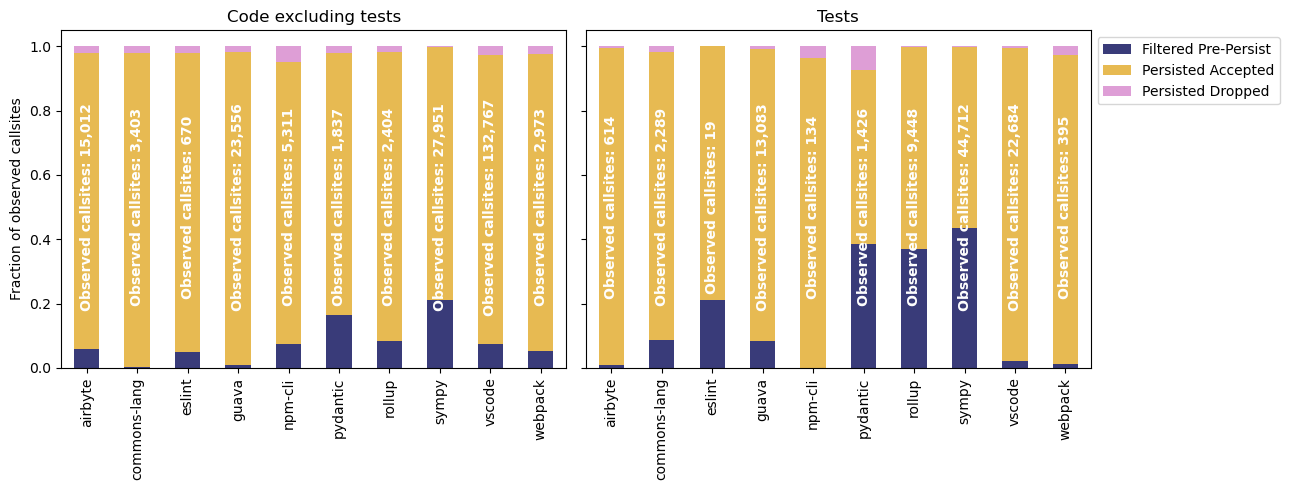

In [ ]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap="tab20b", ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()